# Data volumes and integrations

Shows how to use `NirdaData`, `VisdaData`, and `OverheadTiming` directly —
without running through the full scheduler pipeline — to compute integration
counts and data volumes for a given observation window.

The three classes work independently of any science calendar:

- **`NirdaData`** — detector timing and data volume for one NIRDA observation
- **`VisdaData`** — detector timing and data volume for one VISDA observation
- **`OverheadTiming`** — MOC command-sequence overhead consumed before and after each observation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.time import Time

from shortschedule import NirdaData
from shortschedule.visda import VisdaData
from shortschedule.overhead import OverheadTiming

## Instrument configuration

Both `NirdaData` and `VisdaData` are dataclasses. All timing and per-pixel
geometry are recomputed automatically when a field is changed via
`dataclasses.replace()` or by constructing a new instance. The values below
match the current operational configuration.

In [2]:
# Mission-default NIRDA configuration.
nirda = NirdaData(
    reset_frames_1=50,
    reset_frames_2=1,
    drop_frames_1=1,
    drop_frames_2=16,
    drop_frames_3=0,
    read_frames=4,
    groups=6,
    average_groups=True,
    roi_x_size=80,
    roi_y_size=250,
)

# Mission-default VISDA configuration.
visda = VisdaData(
    frames_per_coadd=50,
    roi_dimension=50,
    num_rois=9,
    exposure_time_s=0.2 * u.s,
)

print('NIRDA')
print(f'  ROI:               {nirda.roi_x_size} x {nirda.roi_y_size} px')
print(f'  pixels/frame:      {nirda.pixels_per_frame}')
print(f'  first int time:    {nirda.first_integration_time.to(u.s).value:.3f} s')
print(f'  other int time:    {nirda.other_integration_time.to(u.s).value:.3f} s')
print(f'  data/integration:  {nirda.integration_data.to(u.byte).value / 1e3:.1f} kB')
print()
print('VISDA')
print(f'  frames/coadd:      {visda.frames_per_coadd}')
print(f'  ROI dimension:     {visda.roi_dimension} px  ({visda.num_rois} ROIs)')
print(f'  pixels/frame:      {visda.pixels_per_frame}')
print(f'  frame time:        {visda.single_frame_time.to(u.s).value:.6f} s')
print(f'  data/frame:        {visda.frame_bytes.to(u.byte).value / 1e3:.1f} kB')

NIRDA
  ROI:               80 x 250 px
  pixels/frame:      23184
  first int time:    35.935 s
  other int time:    24.575 s
  data/integration:  278.2 kB

VISDA
  frames/coadd:      50
  ROI dimension:     50 px  (9 ROIs)
  pixels/frame:      22500
  frame time:        0.200001 s
  data/frame:        90.0 kB


In [3]:
# OverheadTiming models the pre- and post-observation MOC command overhead.
# Defaults come from the commanding timeline. Override individual fields with
# a Quantity to test different timing assumptions (e.g. nirda_pre_overhead_time=200*u.s).
overhead = OverheadTiming()

print('Overhead timing (mission defaults)')
print(f'  NIRDA pre:   {overhead.nirda_pre_overhead_time.to(u.s).value:.0f} s')
print(f'  NIRDA post:  {overhead.nirda_post_overhead_time.to(u.s).value:.0f} s')
print(f'  VISDA pre:   {overhead.visda_pre_overhead_time.to(u.s).value:.0f} s')
print(f'  VISDA post:  {overhead.visda_post_overhead_time.to(u.s).value:.0f} s')

Overhead timing (mission defaults)
  NIRDA pre:   258 s
  NIRDA post:  102 s
  VISDA pre:   260 s
  VISDA post:  102 s


## Observation window

Enter the start and end of the observation window in UTC. The duration is
computed automatically and passed to both instruments below.

In [4]:
# ---------------------------------------------------------------------------
# UPDATE ME: observation window in UTC
# ---------------------------------------------------------------------------
obs_start = Time('2026-06-22T00:00:00Z')
obs_end   = Time('2026-06-22T04:30:00Z')
# ---------------------------------------------------------------------------

duration = (obs_end - obs_start).to(u.s)
print(f'Window:   {obs_start.iso}  ->  {obs_end.iso}')
print(f'Duration: {duration.to(u.min).value:.1f} min  ({duration.value:.0f} s)')

Window:   2026-06-22 00:00:00.000  ->  2026-06-22 04:30:00.000
Duration: 270.0 min  (16200 s)


## Integration counts and data volume

`solve_integrations` subtracts the pre- and post-observation overhead from the
total window, then packs as many integrations (NIRDA) or coadd-aligned frames
(VISDA) as fit in the remaining time. It returns the count, raw data volume,
and compressed data volume.

The compressed volume is what gets downlinked.

In [5]:
# solve_integrations returns (count, raw_bytes, compressed_bytes).
#   NIRDA count = science integrations (dropped-integration buffer already subtracted)
#   VISDA count = total individual frames, floored to whole coadds
nirda_ints, nirda_data_raw, nirda_data_c = nirda.solve_integrations(
    duration, overhead=overhead
)
visda_frames, visda_data_raw, visda_data_c = visda.solve_integrations(
    duration, overhead=overhead
)

pass_data_volume_mb = 281.3  # MB per ground-station pass

nirda_mb_raw = nirda_data_raw.to(u.byte).value / 1e6
nirda_mb_c   = nirda_data_c.to(u.byte).value / 1e6
visda_mb_raw = visda_data_raw.to(u.byte).value / 1e6
visda_mb_c   = visda_data_c.to(u.byte).value / 1e6
total_mb_c   = nirda_mb_c + visda_mb_c

print('NIRDA')
print(f'  integrations:      {nirda_ints}')
print(f'  raw data:          {nirda_mb_raw:.1f} MB')
print(f'  compressed data:   {nirda_mb_c:.1f} MB  (ratio {nirda.compression_ratio})')
print()
print('VISDA')
print(f'  total frames:      {visda_frames}')
print(f'  coadds saved:      {visda_frames // visda.frames_per_coadd}')
print(f'  raw data:          {visda_mb_raw:.1f} MB')
print(f'  compressed data:   {visda_mb_c:.1f} MB  (ratio {visda.compression_ratio})')
print()
print('Combined (compressed)')
print(f'  total:             {total_mb_c:.1f} MB')
print(f'  passes required:   {total_mb_c / pass_data_volume_mb:.2f}  ({pass_data_volume_mb} MB / pass)')

NIRDA
  integrations:      643
  raw data:          178.9 MB
  compressed data:   143.1 MB  (ratio 0.8)

VISDA
  total frames:      79150
  coadds saved:      1583
  raw data:          142.5 MB
  compressed data:   35.6 MB  (ratio 0.25)

Combined (compressed)
  total:             178.7 MB
  passes required:   0.64  (281.3 MB / pass)


## Data volume vs VISDA coadding and NIRDA ROI height

The two instruments contribute to the data budget independently — NIRDA data
depends on ROI size and grouping; VISDA data depends on how many frames are
coadded before downlink. The contour below shows total compressed data in
ground-station passes as both parameters are swept over their usable ranges,
using the observation window defined above.

Because the two contributions are separable, we precompute each instrument's
data volume independently and broadcast across the grid rather than looping
over every combination.

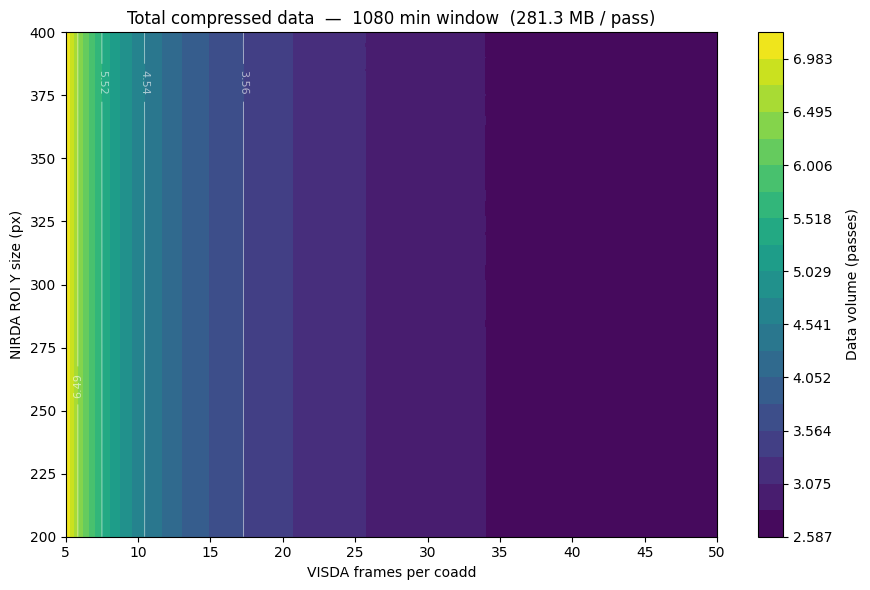

In [11]:
pass_data_volume_mb = 281.3  # MB per pass

# Look at roughly a full's day of data
duration = (0.75 * u.day).to(u.s)

fpc_values   = np.arange(5, 51, dtype=int)        # VISDA frames_per_coadd: 1 -> 50
roi_y_values = np.arange(200, 405, 5, dtype=int)  # NIRDA roi_y_size: 200 -> 400 (step 5)

# NIRDA data depends only on roi_y_size; compute one value per row.
nirda_dc_bytes = np.zeros(len(roi_y_values))
for i, roi_y in enumerate(roi_y_values):
    n = NirdaData(roi_y_size=int(roi_y))
    _, _, dc = n.solve_integrations(duration, overhead=overhead)
    nirda_dc_bytes[i] = dc.to(u.byte).value

# VISDA data depends only on frames_per_coadd; compute one value per column.
visda_dc_bytes = np.zeros(len(fpc_values))
for j, fpc in enumerate(fpc_values):
    v = VisdaData(frames_per_coadd=int(fpc))
    _, _, dc = v.solve_integrations(duration, overhead=overhead)
    visda_dc_bytes[j] = dc.to(u.byte).value

# Broadcast: total passes at every (roi_y, fpc) grid point.
passes_grid = (
    (nirda_dc_bytes[:, np.newaxis] + visda_dc_bytes[np.newaxis, :]) / 1e6
    / pass_data_volume_mb
)

fig, ax = plt.subplots(figsize=(9, 6))

levels = np.linspace(passes_grid.min(), passes_grid.max(), 20)
cf = ax.contourf(fpc_values, roi_y_values, passes_grid, levels=levels, cmap='viridis')
cs = ax.contour(
    fpc_values, roi_y_values, passes_grid,
    levels=levels[::4], colors='white', linewidths=0.6, alpha=0.6,
)
ax.clabel(cs, fmt='%.2f', fontsize=8, inline=True)

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label('Data volume (passes)', labelpad=10)

ax.set_xlabel('VISDA frames per coadd')
ax.set_ylabel('NIRDA ROI Y size (px)')
ax.set_title(
    f'Total compressed data  —  {duration.to(u.min).value:.0f} min window'
    f'  ({pass_data_volume_mb} MB / pass)'
)

plt.tight_layout()
plt.show()